PA-FH probability vector:
[0.36  0.267 0.146 0.108 0.044 0.033 0.024 0.018]


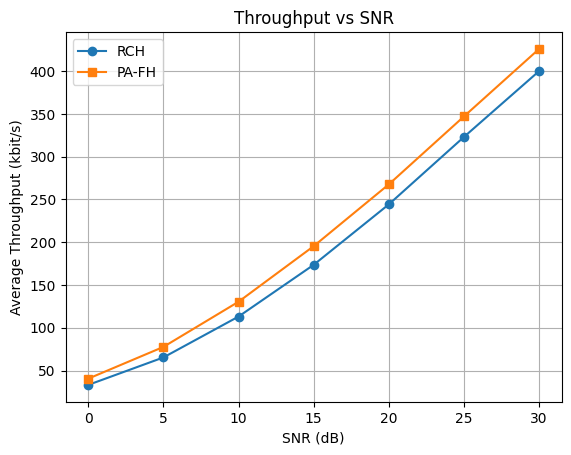

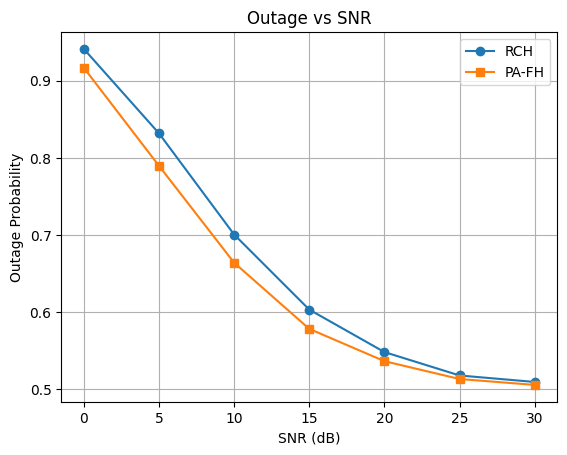

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. Simulation parameters
# =========================

K = 8                       # number of channels
B = 100e3                   # bandwidth = 100 kHz
N_slots = 100_000           # Monte Carlo slots
noise_dBm = -90
Pj_dBm = 25                 # jammer power
gamma_th_dB = 3             # outage threshold
beta = 3                    # softmax parameter

noise = 10 ** ((noise_dBm - 30) / 10)
Pj = 10 ** ((Pj_dBm - 30) / 10)
gamma_th = 10 ** (gamma_th_dB / 10)

snr_dB_range = np.arange(0, 31, 5)


# =========================
# 2. Helper functions
# =========================

def softmax(u, beta):
    x = beta * u
    x = x - np.max(x)       # avoid overflow
    e = np.exp(x)
    return e / np.sum(e)


def simulate_scheme(snr_dB, scheme="RCH"):
    Ps = noise * 10 ** (snr_dB / 10)

    # long-term channel quality / utility
    # giả lập vài kênh tốt, vài kênh xấu
    avg_channel_quality = np.array([1.4, 1.3, 1.1, 1.0, 0.7, 0.6, 0.5, 0.4])

    if scheme == "RCH":
        p = np.ones(K) / K

    elif scheme == "PAFH":
        utility = avg_channel_quality
        p = softmax(utility, beta)

    else:
        raise ValueError("Unknown scheme")

    throughput = []
    outages = 0

    for _ in range(N_slots):
        # chọn channel theo xác suất p
        k = np.random.choice(K, p=p)

        # Rayleigh fading: |h|^2 ~ exponential(1)
        h_st = np.random.exponential(1)
        h_tr = np.random.exponential(1)
        h_jr = np.random.exponential(1)

        # dyadic backscatter channel
        h_bs_power = h_st * h_tr

        # jammer activity: giả sử jammer active với xác suất 0.5
        jammer_active = np.random.rand() < 0.5

        interference = Pj * h_jr if jammer_active else 0

        sinr = (Ps * avg_channel_quality[k] * h_bs_power) / (noise + interference)

        rate = B * np.log2(1 + sinr)
        throughput.append(rate)

        if sinr < gamma_th:
            outages += 1

    avg_throughput = np.mean(throughput)
    outage_prob = outages / N_slots

    return avg_throughput, outage_prob, p


# =========================
# 3. Run simulation
# =========================

throughput_rch = []
throughput_pafh = []

outage_rch = []
outage_pafh = []

for snr_dB in snr_dB_range:
    th_rch, out_rch, _ = simulate_scheme(snr_dB, "RCH")
    th_pafh, out_pafh, p_pafh = simulate_scheme(snr_dB, "PAFH")

    throughput_rch.append(th_rch / 1e3)      # kbit/s
    throughput_pafh.append(th_pafh / 1e3)

    outage_rch.append(out_rch)
    outage_pafh.append(out_pafh)


print("PA-FH probability vector:")
print(np.round(p_pafh, 3))


# =========================
# 4. Plot throughput
# =========================

plt.figure()
plt.plot(snr_dB_range, throughput_rch, marker="o", label="RCH")
plt.plot(snr_dB_range, throughput_pafh, marker="s", label="PA-FH")
plt.xlabel("SNR (dB)")
plt.ylabel("Average Throughput (kbit/s)")
plt.title("Throughput vs SNR")
plt.legend()
plt.grid(True)
plt.show()


# =========================
# 5. Plot outage
# =========================

plt.figure()
plt.plot(snr_dB_range, outage_rch, marker="o", label="RCH")
plt.plot(snr_dB_range, outage_pafh, marker="s", label="PA-FH")
plt.xlabel("SNR (dB)")
plt.ylabel("Outage Probability")
plt.title("Outage vs SNR")
plt.legend()
plt.grid(True)
plt.show()

Probability vectors:
NAJ [1. 0. 0. 0. 0. 0. 0. 0.]
SCS [1. 0. 0. 0. 0. 0. 0. 0.]
RCH [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
PAFH [0.416 0.261 0.15  0.09  0.033 0.021 0.016 0.013]


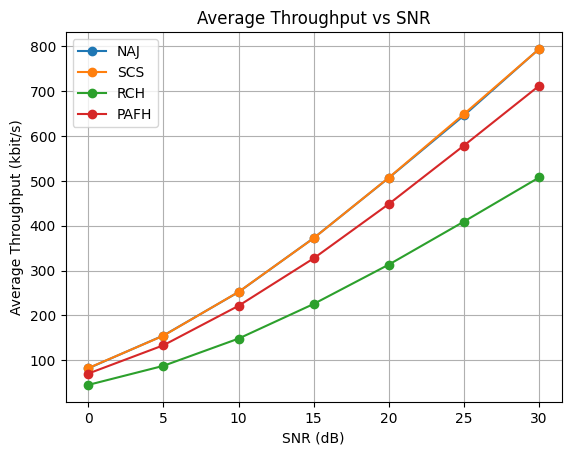

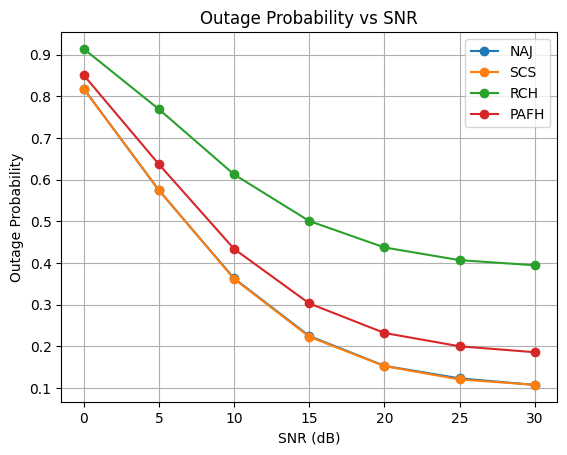

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# =====================
# Parameters
# =====================

K = 8
B = 100e3
N_slots = 100_000

noise_dBm = -90
Pj_dBm = 25
gamma_th_dB = 3
beta = 3

noise = 10 ** ((noise_dBm - 30) / 10)
Pj = 10 ** ((Pj_dBm - 30) / 10)
gamma_th = 10 ** (gamma_th_dB / 10)

snr_dB_range = np.arange(0, 31, 5)

# Giả lập chất lượng trung bình của 8 kênh
channel_quality = np.array([1.4, 1.3, 1.15, 1.0, 0.75, 0.6, 0.5, 0.4])

# Giả lập xác suất jammer xuất hiện trên từng kênh
jammer_prob = np.array([0.10, 0.15, 0.20, 0.25, 0.45, 0.55, 0.65, 0.75])


# =====================
# Helper functions
# =====================

def softmax(u, beta):
    x = beta * u
    x = x - np.max(x)
    e = np.exp(x)
    return e / np.sum(e)


def get_probability_vector(scheme):
    if scheme == "NAJ":
        # Không hopping, dùng kênh đầu tiên
        p = np.zeros(K)
        p[0] = 1.0
        return p

    if scheme == "SCS":
        # Static Channel Selection: chọn kênh tốt nhất theo utility
        best_k = np.argmax(channel_quality * (1 - jammer_prob))
        p = np.zeros(K)
        p[best_k] = 1.0
        return p

    if scheme == "RCH":
        # Random Channel Hopping
        return np.ones(K) / K

    if scheme == "PAFH":
        # Utility: kênh tốt và ít bị jammer thì utility cao
        utility = channel_quality * (1 - jammer_prob)
        return softmax(utility, beta)

    raise ValueError("Unknown scheme")


def simulate(snr_dB, scheme):
    Ps = noise * 10 ** (snr_dB / 10)
    p = get_probability_vector(scheme)

    total_rate = 0.0
    outage_count = 0

    for _ in range(N_slots):
        k = np.random.choice(K, p=p)

        # Rayleigh fading power gains
        h_st = np.random.exponential(1)
        h_tr = np.random.exponential(1)
        h_jr = np.random.exponential(1)

        # Backscatter dyadic channel
        h_bs_power = h_st * h_tr

        # Jammer active trên channel k theo xác suất jammer_prob[k]
        jammer_active = np.random.rand() < jammer_prob[k]
        interference = Pj * h_jr if jammer_active else 0.0

        sinr = (Ps * channel_quality[k] * h_bs_power) / (noise + interference)

        rate = B * np.log2(1 + sinr)
        total_rate += rate

        if sinr < gamma_th:
            outage_count += 1

    avg_throughput = total_rate / N_slots
    outage_prob = outage_count / N_slots

    return avg_throughput, outage_prob


# =====================
# Run
# =====================

schemes = ["NAJ", "SCS", "RCH", "PAFH"]

throughput_results = {s: [] for s in schemes}
outage_results = {s: [] for s in schemes}

for snr_dB in snr_dB_range:
    for scheme in schemes:
        th, out = simulate(snr_dB, scheme)
        throughput_results[scheme].append(th / 1e3)
        outage_results[scheme].append(out)

print("Probability vectors:")
for s in schemes:
    print(s, np.round(get_probability_vector(s), 3))


# =====================
# Plot Throughput
# =====================

plt.figure()
for scheme in schemes:
    plt.plot(snr_dB_range, throughput_results[scheme], marker="o", label=scheme)

plt.xlabel("SNR (dB)")
plt.ylabel("Average Throughput (kbit/s)")
plt.title("Average Throughput vs SNR")
plt.grid(True)
plt.legend()
plt.show()


# =====================
# Plot Outage
# =====================

plt.figure()
for scheme in schemes:
    plt.plot(snr_dB_range, outage_results[scheme], marker="o", label=scheme)

plt.xlabel("SNR (dB)")
plt.ylabel("Outage Probability")
plt.title("Outage Probability vs SNR")
plt.grid(True)
plt.legend()
plt.show()